<h2>Лабораторна робота №8</h2>
<h3>Застосування генетичних алгоритмів в задачах оптимізації</h3>

CSV містить результати експериментів. Створюю тестову матрицю зв'язності для Варіанту 5...
Запуск оптимізації...
Фінальна довжина з'єднань: 1896.04
Фінальна площа перекриття: 0.00


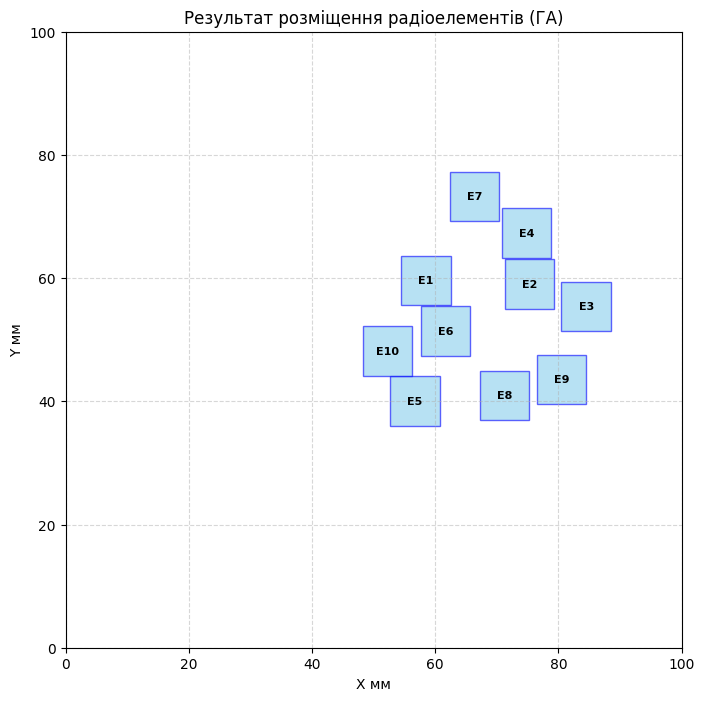

In [5]:
import pandas as pd # Імпортується бібліотека Pandas для зчитування та обробки табличних даних (CSV-файл)
import numpy as np # Імпортується NumPy для числових обчислень, роботи з масивами та математичними функціями
import random # Імпортується стандартний модуль Python для генерації випадкових чисел (використовується у ГА)
import matplotlib.pyplot as plt # Імпортується бібліотека Matplotlib для побудови графіків та візуалізації
import matplotlib.patches as patches # Імпортується модуль для малювання геометричних фігур (прямокутників)

import warnings # Імпортується модуль для керування системними попередженнями
warnings.filterwarnings("ignore") # Вимикаються всі попередження, щоб вони не відображались у консолі

# Завантаження даних 
# Оголошується функція load_connectivity_matrix для завантаження матриці зв’язності з CSV-файлу
# Зчитується CSV-файл у DataFrame; перший стовпець використовується як індекси (назви елементів)
#  df = pd.read_csv(file_path, index_col=0)
# Перевіряється: 
# чи файл містить експериментальні дані, або чи не є матриця квадратною (тобто не є матрицею суміжності)
# if 'ExperimentNo' in df.columns or df.shape[0] != df.shape[1]:
# Виводиться повідомлення про створення тестових даних
# print("CSV містить результати експериментів. Створюю тестову матрицю зв'язності для Варіанту 5...")
# Задається кількість елементів схеми: size = 10
# Формується список міток елементів (E1, E2, ..., E10): labels = [f"E{i+1}" for i in range(size)]
# Створюється випадкова матриця зв’язності з вагами від 0 до 4:  matrix = np.random.randint(0, 5, size=(size, size))
# Зануляється головна діагональ (елемент не з’єднаний сам із собою): np.fill_diagonal(matrix, 0)
# Повертається матриця зв’язності та список елементів: return matrix, labels
# Якщо CSV коректний — повертається матриця та назви елементів з файлу: return df.values, df.index.tolist()
def load_connectivity_matrix(file_path):
    # Зчитуємо CSV. Припускаємо, що перший стовпець - це назви елементів
    df = pd.read_csv(file_path, index_col=0)
    # Якщо у файлі є порожні рядки або підписи, 
    # код нижче створює тестову матрицю зв'язності для демонстрації, 
    # якщо структура CSV не є прямою матрицею суміжності.
    if 'ExperimentNo' in df.columns or df.shape[0] != df.shape[1]:
        print("CSV містить результати експериментів. Створюю тестову матрицю зв'язності для Варіанту 5...")
        size = 10
        labels = [f"E{i+1}" for i in range(size)]
        matrix = np.random.randint(0, 5, size=(size, size))
        np.fill_diagonal(matrix, 0)
        return matrix, labels
    return df.values, df.index.tolist()

# Налаштування задачі 
FIELD_SIZE = 100 # Розмір графіка (плати): 100×100 мм
ELEMENT_DIM = 8  # Розмір квадратного елемента (8×8 мм)

# Оголошується клас GeneticPlacement, що реалізує генетичний алгоритм розміщення елементів
# Конструктор класу (Ініціалізація об’єкта): matrix — матриця зв’язності, labels — імена елементів,
#                                            pop_size — розмір популяції, mut_rate — ймовірність мутації
# Збереження матриці та міток у властивостях класу: self.matrix = matrix, self.labels = labels
# Кількість елементів у схемі: self.n_elements = len(labels)
# Збереження параметрів генетичного алгоритму: self.pop_size = pop_size, self.mut_rate = mut_rate
# Ініціалізація початкової популяції: self.population = self._init_population()
class GeneticPlacement:
    def __init__(self, matrix, labels, pop_size=60, mut_rate=0.25):
        self.matrix = matrix
        self.labels = labels
        self.n_elements = len(labels)
        self.pop_size = pop_size
        self.mut_rate = mut_rate
        self.population = self._init_population()

# Оголошується метод створення початкової популяції _init_population
# Порожній список для популяції: pop = []
# Генерується pop_size хромосом:  for _ in range(self.pop_size):
# Генерується випадкова координата X елемента: chromosome = [[random.uniform(0, FIELD_SIZE - ELEMENT_DIM),
# Генерується випадкова координата Y елемента: random.uniform(0, FIELD_SIZE - ELEMENT_DIM)]
# Формується список координат для всіх елементів: for _ in range(self.n_elements)]
# Хромосома додається до популяції: pop.append(chromosome)
# Повертається початкова популяція: return pop
    def _init_population(self):
        pop = []
        for _ in range(self.pop_size):
            chromosome = [[random.uniform(0, FIELD_SIZE - ELEMENT_DIM), 
                          random.uniform(0, FIELD_SIZE - ELEMENT_DIM)] 
                          for _ in range(self.n_elements)]
            pop.append(chromosome)
        return pop

# Оголошується метод обчислення сумарної довжини з’єднань _calculate_length
# Ініціалізація сумарної довжини: total_l = 0
# Перебір усіх пар елементів без повторів: два цикла for вкладених один до одного (дворівневих)
# Перевірка, чи існує з’єднання між елементами: if self.matrix[i][j] > 0:
# Обчислення евклідової відстані між елементами: dist
# Додається зважена довжина з’єднання: total_l += dist * self.matrix[i][j]
# Повертається загальна довжина з’єднань: return total_l 
    def _calculate_length(self, chromosome):
        total_l = 0
        for i in range(self.n_elements):
            for j in range(i + 1, self.n_elements):
                if self.matrix[i][j] > 0:
                    dist = np.sqrt((chromosome[i][0] - chromosome[j][0])**2 + 
                                   (chromosome[i][1] - chromosome[j][1])**2)
                    total_l += dist * self.matrix[i][j]
        return total_l

# Оголошується метод обчислення площі перекриття елементів _calculate_overlap
# Початкове значення перекриття: overlap_penalty = 0
# Перевірка всіх пар елементів: два цикла for вкладених один до одного (дворівневих)
# Обчислення перекриття по осі X: dx = max(0, ELEMENT_DIM - abs(chromosome[i][0] - chromosome[j][0]))
# Обчислення перекриття по осі Y: dy = max(0, ELEMENT_DIM - abs(chromosome[i][1] - chromosome[j][1]))
# Додається площа перекриття: overlap_penalty += dx * dy
# Повертається сумарне перекриття: return overlap_penalty
    def _calculate_overlap(self, chromosome):
        overlap_penalty = 0
        for i in range(self.n_elements):
            for j in range(i + 1, self.n_elements):
                dx = max(0, ELEMENT_DIM - abs(chromosome[i][0] - chromosome[j][0]))
                dy = max(0, ELEMENT_DIM - abs(chromosome[i][1] - chromosome[j][1]))
                overlap_penalty += dx * dy
        return overlap_penalty

# Оголошується метод fitness для генетичного алгоритму
# Обчислюється довжина з’єднань: L = self._calculate_length(chromosome)
# Обчислюється перекриття: S = self._calculate_overlap(chromosome)
# Повертає результат
# Формула пристосованості: мінімізує довжину, сильно штрафує перекриття,
# приводить задачу до максимізації
    def fitness(self, chromosome):
        L = self._calculate_length(chromosome)
        S = self._calculate_overlap(chromosome)
        return 1 / (L + S * 50 + 1)

# Оголошується метод запуску еволюції evolve
# Цикл по поколіннях: for gen in range(generations):
# Сортування популяції за спаданням fitness: 
# self.population = sorted(self.population, key=lambda x: self.fitness(x), reverse=True)
# Збереження 10 найкращих рішень (елітність): new_gen = self.population[:10]
# Генерація нових особин:  while len(new_gen) < self.pop_size:
# Вибір двох батьків із найкращих: p1, p2 = random.sample(self.population[:25], 2)
# Точка кросоверу: cut = random.randint(1, self.n_elements - 1)
# Створення нащадка: child = p1[:cut] + p2[cut:]
# Ймовірність мутації: if random.random() < self.mut_rate:
# Вибір гена для мутації: idx = random.randint(0, self.n_elements - 1)
# Заміна координат елемента: child[idx]
# Додавання нащадка до популяції: new_gen.append(child)
# Оновлення популяції: self.population = new_gen
# Повертається найкраще рішення: return self.population[0]
    def evolve(self, generations=200):
        for gen in range(generations):
            self.population = sorted(self.population, key=lambda x: self.fitness(x), reverse=True)
            new_gen = self.population[:10] # Елітарність

            while len(new_gen) < self.pop_size:
                p1, p2 = random.sample(self.population[:25], 2)
                cut = random.randint(1, self.n_elements - 1)
                child = p1[:cut] + p2[cut:]
                
                if random.random() < self.mut_rate:
                    idx = random.randint(0, self.n_elements - 1)
                    child[idx] = [random.uniform(0, FIELD_SIZE - ELEMENT_DIM), 
                                 random.uniform(0, FIELD_SIZE - ELEMENT_DIM)]
                new_gen.append(child)
            self.population = new_gen
        return self.population[0]

# Оголошується метод для відображення результату visualize_placement
# Створення графічного вікна: fig, ax = plt.subplots(figsize=(8, 8))
# Встановлення меж плати: ax.set_xlim(0, FIELD_SIZE), ax.set_ylim(0, FIELD_SIZE)
# Однаковий масштаб осей: ax.set_aspect('equal')
# Заголовок графіка: ax.set_title("Результат розміщення радіоелементів (ГА)")
# Перебір елементів: for i, (x, y) in enumerate(best_coords):
# Малювання квадратного елемента: rect = patches.Rectangle((x, y), ELEMENT_DIM, ELEMENT_DIM, ...)
# Додавання квадрата на графік: ax.add_patch(rect)
# Виведення підпису елемента: ax.text(...)
def visualize_placement(best_coords, labels):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(0, FIELD_SIZE)
    ax.set_ylim(0, FIELD_SIZE)
    ax.set_aspect('equal')
    ax.set_title("Результат розміщення радіоелементів (ГА)")
    ax.set_xlabel("X мм") # Підпис осі X
    ax.set_ylabel("Y мм") # Підпис осі Y

    for i, (x, y) in enumerate(best_coords):
        # Малюємо елемент як квадрат
        rect = patches.Rectangle((x, y), ELEMENT_DIM, ELEMENT_DIM, 
                                 linewidth=1, edgecolor='blue', facecolor='skyblue', alpha=0.6)
        ax.add_patch(rect)
        ax.text(x + ELEMENT_DIM/2, y + ELEMENT_DIM/2, labels[i], 
                ha='center', va='center', fontsize=8, fontweight='bold')

    plt.grid(True, linestyle='--', alpha=0.5) # Вмикається відображення сітки на графіку
    plt.show() # Зображується графік

# Виконання 
if __name__ == "__main__": # Перевірка, що файл запущено напряму
    try: # Початок блоку обробки помилок
        # Завантаження даних
        matrix, labels = load_connectivity_matrix('ElectricSchemeGA.csv')
        # Створення об’єкта ГА
        ga = GeneticPlacement(matrix, labels)
        
        print("Запуск оптимізації...") # Повідомлення про запуск оптимізації
        best_sol = ga.evolve(generations=150) # Запуск оптимізації

        # Виведення повідомлень та фінальних метрик
        print(f"Фінальна довжина з'єднань: {ga._calculate_length(best_sol):.2f}")
        print(f"Фінальна площа перекриття: {ga._calculate_overlap(best_sol):.2f}")
        
        # Візуалізація рішення
        visualize_placement(best_sol, labels)

    # Обробка можливих помилок
    except Exception as e:
        print(f"Виникла помилка: {e}") # Виведення повідомлення про помилку

# ==============================================================================
# КОНТРОЛЬНІ ЗАПИТАННЯ:
# ==============================================================================
# 1. Сутність задач оптимізації за допомогою ГА полягає у пошуку найкращого (глобального) 
#    рішення серед безлічі можливих шляхом імітації природного відбору.
# 2. ГА ефективні для багатопараметричних задач, оскільки вони досліджують багато областей 
#    простору рішень одночасно, не вимагаючи похідних функцій.
# 3. Традиційні методи (наприклад, градієнтний спуск) часто застрягають у локальних мінімумах, 
#    тоді як ГА краще знаходять глобальний екстремум.
# 4. Функція пристосованості визначає, наскільки «хорошим» є конкретне рішення відносно мети.
# 5. Правильний вибір функції пристосованості критичний, бо він спрямовує еволюцію. 
#    Якщо вона некоректна, алгоритм знайде хибне рішення.
# 6. Мутація дозволяє «стрибати» у нові області простору, виходячи за межі локальних екстремумів.
# 7. Найчастіше: нелінійні, багатокритеріальні та дискретні задачі (наприклад, задача комівояжера).
# 8. Кросовер комбінує ознаки двох хороших рішень, сподіваючись отримати ще кращого нащадка.
# 9. Мутація вносить випадкові зміни, підтримуючи генетичне різноманіття популяції.
# 10. Приклади: компонування мікросхем, проектування крил літака, оптимізація форм антен.
# 11. У логістиці ГА шукають найкоротші маршрути (TSP) з урахуванням багатьох обмежень.
# 12. ГА є частиною еволюційних обчислень і часто комбінуються з іншими методами для швидкості.
# 13. Великий розмір популяції покращує пошук, але сповільнює роботу. Висока мутація робить 
#     пошук випадковим, низька — веде до передчасної збіжності.
# 14. Перевага ГА в багатокритеріальності — можливість знаходження множини Парето (компромісних рішень).
# 15. Сфери: економічне моделювання, автоматизація проектування (CAD), розшифровка геному, 
#     тренування нейронних мереж.
# ==============================================================================

<h2>Виконала студентка групи ЗПІ-зп41  <br>Грищенко Юлія</h2>
